In [49]:
!pip install category_encoders

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import re


In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
#مسار البيانات
path = '/content/drive/MyDrive/Colab Notebooks/Mobile phone price.csv'

# قراءة الملف
df = pd.read_csv(path)

# عرض البيانات للتأكد
df.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [52]:
# 1. دالة تنظيف الأرقام
def advanced_clean(value):
    if pd.isna(value):
        return np.nan

    numbers = re.findall(r'\d+\.?\d*', str(value))
    return float(numbers[0]) if numbers else np.nan

# 2. تنظيف الأعمدة الرقمية
cols_to_clean = ['Price ($)', 'RAM ', 'Storage ', 'Battery Capacity (mAh)', 'Camera (MP)']
for col in cols_to_clean:
    df[col] = df[col].apply(advanced_clean)

# 3. تنظيف الأعمدة النصية
for col in ['Brand', 'Model']:
    df[col] = df[col].str.strip().str.title()
    df[col] = df[col].fillna("Unknown")

# 4. ملء القيم المفقودة
df.fillna(df.mean(numeric_only=True), inplace=True)

print(" تم الانتهاء من التنظيف الشامل بنجاح.")

 تم الانتهاء من التنظيف الشامل بنجاح.


In [53]:
le_brand = LabelEncoder()
le_model = LabelEncoder()

# تحويل النصوص إلى أرقام
df['Brand_Enc'] = le_brand.fit_transform(df['Brand'])
df['Model_Enc'] = le_model.fit_transform(df['Model'])

print("تم تحويل الماركة والموديل إلى أرقام بنجاح.")
print(f"عدد الماركات الفريدة التي تم معالجتها: {len(le_brand.classes_)}")

تم تحويل الماركة والموديل إلى أرقام بنجاح.
عدد الماركات الفريدة التي تم معالجتها: 16


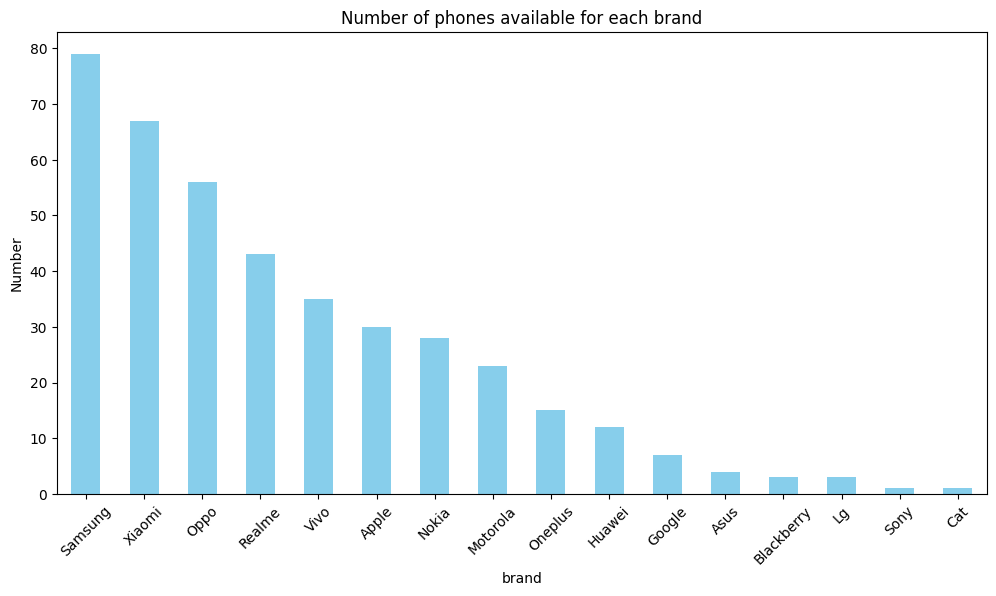

In [54]:
plt.figure(figsize=(12,6))
df['Brand'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Number of phones available for each brand")
plt.xlabel("brand")
plt.ylabel("Number")
plt.xticks(rotation=45)
plt.show()

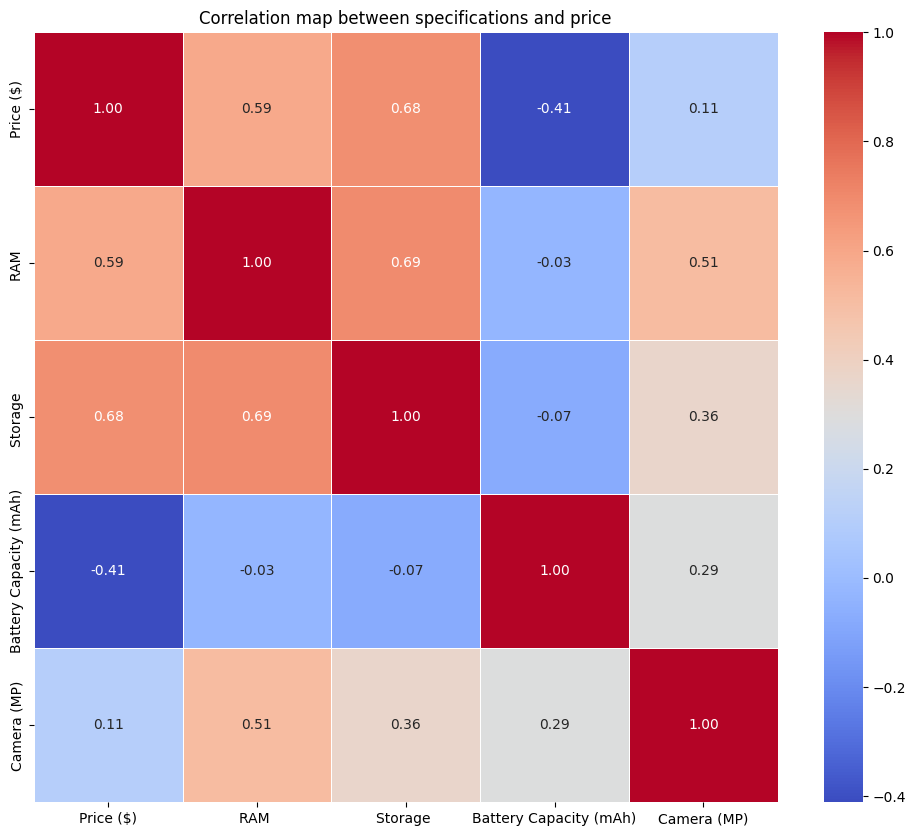

In [55]:
plt.figure(figsize=(12,10))

corr_cols = ['Price ($)', 'RAM ', 'Storage ', 'Battery Capacity (mAh)', 'Camera (MP)']
corr = df[corr_cols].corr()

# رسم الخريطة
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation map between specifications and price")
plt.show()

In [56]:
features = ['Brand_Enc', 'Model_Enc', 'RAM ', 'Storage ', 'Battery Capacity (mAh)', 'Camera (MP)']
X = df[features]
y = df['Price ($)']

#  تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  تدريب نموذج
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#  النتائج
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred) * 100
mae = mean_absolute_error(y_test, y_pred)

print(f"دقة النموذج النهائية: {accuracy:.2f}%")
print(f"متوسط الخطأ في التنبؤ: {mae:.2f}$")

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nالعوامل الأكثر تأثيراً في السعر حسب النموذج:")
print(importances)

دقة النموذج النهائية: 79.11%
متوسط الخطأ في التنبؤ: 64.16$

العوامل الأكثر تأثيراً في السعر حسب النموذج:
Storage                   0.425984
Battery Capacity (mAh)    0.157214
Brand_Enc                 0.153619
RAM                       0.140496
Model_Enc                 0.079245
Camera (MP)               0.043442
dtype: float64
